In [ ]:
# ============================================================
# PETS FACIAL EXPRESSION CLASSIFICATION
# ============================================================
# Assignment: Build 5 well-known networks from scratch, evaluate them,
# and apply transfer learning to the best performer.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# PyTorch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset, random_split
from torchvision import transforms, datasets, models
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Metrics
from sklearn.metrics import (confusion_matrix, classification_report, precision_score, recall_score, f1_score, accuracy_score)

# Set seeds for reproducibility
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
EXCLUDED_CLASS = "Master Folder"

# Device configuration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Using device: cuda
GPU: Tesla P100-PCIE-16GB


In [2]:
# ============================================================
# CONFIGURATION
# ============================================================

# Paths (Kaggle)
DATA_DIR = '/kaggle/input/pets-facial-expression-dataset'

# Hyperparameters
IMG_SIZE = 224
BATCH_SIZE = 32
NUM_EPOCHS = 50
LEARNING_RATE = 1e-3
NUM_WORKERS = 2
VAL_SPLIT = 0.2

# Data Augmentation
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [5]:
# Load dataset
full_dataset = datasets.ImageFolder(DATA_DIR, transform=train_transforms)
# Get index of excluded class
excluded_idx = full_dataset.class_to_idx[EXCLUDED_CLASS]

# Keep only samples NOT in Master Folder
filtered_samples = [
    (path, label)
    for path, label in full_dataset.samples
    if label != excluded_idx
]

# Replace internal dataset storage
full_dataset.samples = filtered_samples
full_dataset.imgs = filtered_samples

# Remove class name
full_dataset.classes = [
    cls for cls in full_dataset.classes if cls != EXCLUDED_CLASS
]

# Rebuild class_to_idx mapping
full_dataset.class_to_idx = {
    cls: i for i, cls in enumerate(full_dataset.classes)
}

# Remap labels to new indices
new_samples = []
for path, old_label in full_dataset.samples:
    class_name = path.split("/")[-2]
    new_label = full_dataset.class_to_idx[class_name]
    new_samples.append((path, new_label))

full_dataset.samples = new_samples
full_dataset.imgs = new_samples

class_names = full_dataset.classes
num_classes = len(class_names)

print(f"Number of classes: {num_classes}")
print(f"Classes: {class_names}")
print(f"Total images: {len(full_dataset)}")


Number of classes: 4
Classes: ['Angry', 'Other', 'Sad', 'happy']
Total images: 1000


In [19]:
val_size = int(VAL_SPLIT * len(full_dataset))
train_size = len(full_dataset) - val_size

train_dataset, val_dataset = random_split(
    full_dataset,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply validation transforms
val_dataset.dataset.transform = val_transforms

print(f"\nTrain size: {len(train_dataset)}")
print(f"Validation size: {len(val_dataset)}")





Train size: 800
Validation size: 200


In [21]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=True
)
print("done")

done


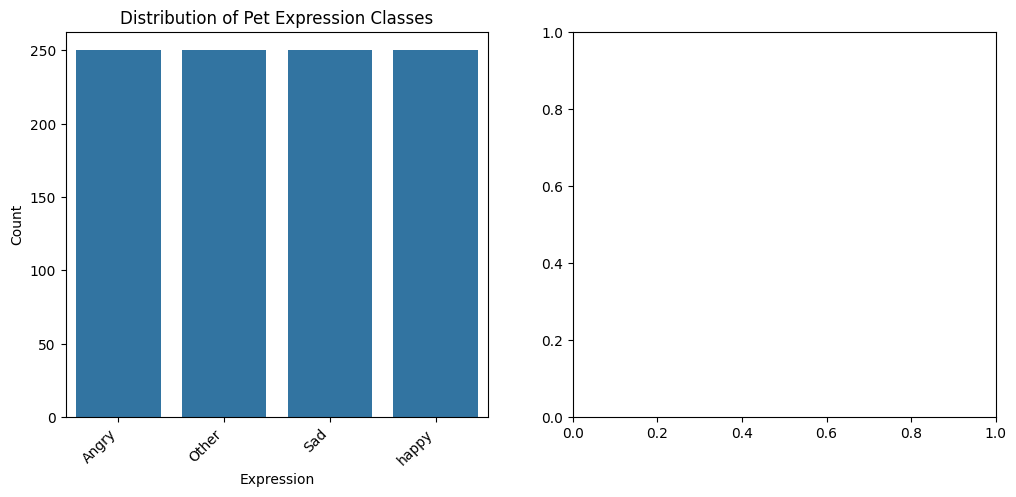

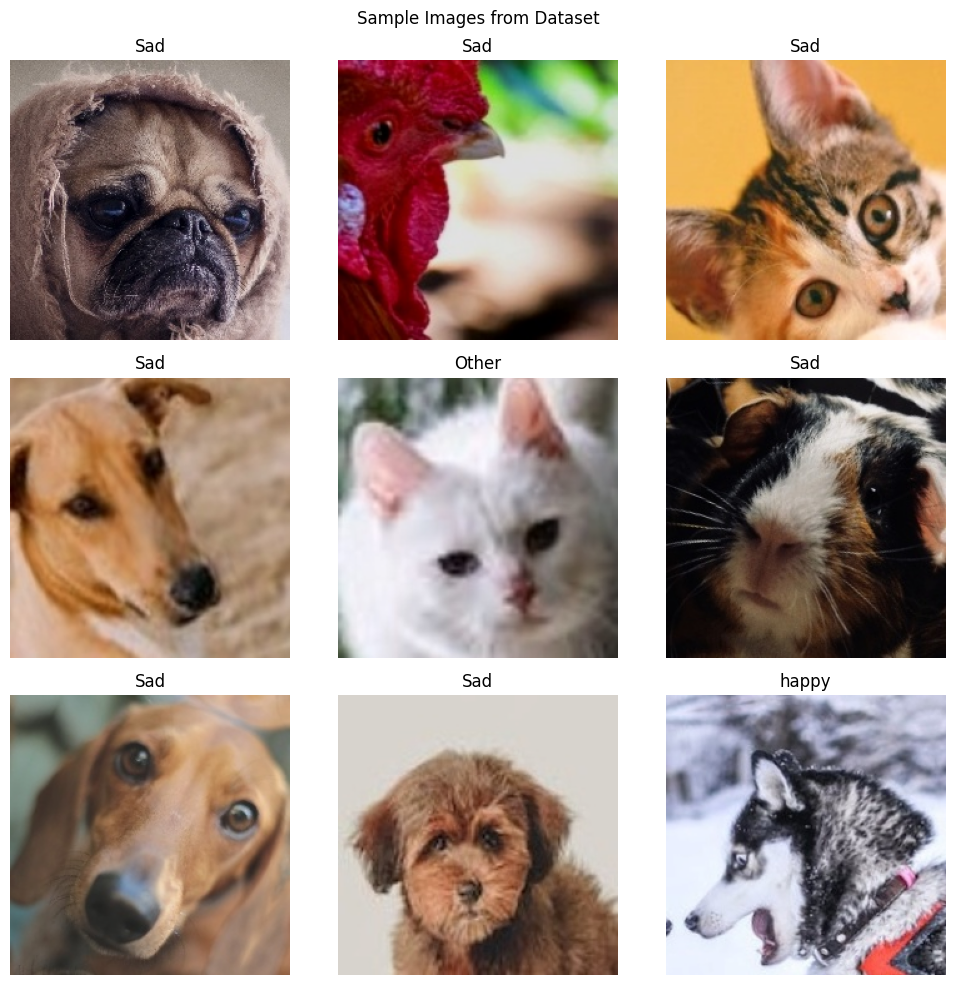

In [7]:
# Count images per class
class_counts = {}
for img_path, label in full_dataset.imgs:
    class_name = class_names[label]
    class_counts[class_name] = class_counts.get(class_name, 0) + 1

# Plot distribution
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.barplot(x=list(class_counts.keys()), y=list(class_counts.values()))
plt.title('Distribution of Pet Expression Classes')
plt.xlabel('Expression')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')

# Show sample images
plt.subplot(1, 2, 2)
sample_indices = np.random.choice(len(full_dataset), 9, replace=False)
fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for idx, ax in enumerate(axes.flat):
    img, label = full_dataset[sample_indices[idx]]
    # Denormalize for visualization
    img = img.numpy().transpose(1, 2, 0)
    img = img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)
    ax.imshow(img)
    ax.set_title(class_names[label])
    ax.axis('off')
plt.suptitle('Sample Images from Dataset')
plt.tight_layout()
plt.show()

# Part 2: Building Well-Known Networks from Scratch

We will implement the following 5 architectures from scratch:
1. **VGG** (Visual Geometry Group) - Deep network with 3x3 convolutions
2. **ResNet** (Residual Network) - Skip connections to enable very deep networks
3. **MobileNet** - Depthwise separable convolutions for efficiency
4. **Inception V3** - Multiple parallel convolution branches
5. **DenseNet** - Dense connections between all layers

In [9]:

# 1. VGG NETWORK (from scratch)
class VGG(nn.Module):
    """
    VGG-style network with configurable depth.
    Uses 3x3 convolutions and 2x2 max pooling.
    """
    def __init__(self, num_classes):
        super(VGG, self).__init__()
        
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.BatchNorm2d(512),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.avgpool = nn.AdaptiveAvgPool2d((7, 7))
        
        self.classifier = nn.Sequential(
            nn.Linear(512 * 7 * 7, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, num_classes),
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.classifier(x)
        return x

print("VGG Network defined")

VGG Network defined


In [10]:
# 2. RESNET (from scratch)

class BasicBlock(nn.Module):
    """Basic ResNet block with skip connection"""
    expansion = 1
    
    def __init__(self, in_channels, out_channels, stride=1, downsample=None):
        super(BasicBlock, self).__init__()
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, 
                               stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, 
                               stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.downsample = downsample
    
    def forward(self, x):
        identity = x
        
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        
        out = self.conv2(out)
        out = self.bn2(out)
        
        if self.downsample is not None:
            identity = self.downsample(x)
        
        out += identity  # Skip connection
        out = self.relu(out)
        
        return out

class ResNet(nn.Module):
    """ResNet-18 style architecture"""
    def __init__(self, num_classes, layers=[2, 2, 2, 2]):
        super(ResNet, self).__init__()
        self.in_channels = 64
        
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        # ResNet layers
        self.layer1 = self._make_layer(64, layers[0])
        self.layer2 = self._make_layer(128, layers[1], stride=2)
        self.layer3 = self._make_layer(256, layers[2], stride=2)
        self.layer4 = self._make_layer(512, layers[3], stride=2)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(512, num_classes)
        
        # Initialize weights
        self._initialize_weights()
    
    def _make_layer(self, out_channels, blocks, stride=1):
        downsample = None
        if stride != 1 or self.in_channels != out_channels:
            downsample = nn.Sequential(
                nn.Conv2d(self.in_channels, out_channels, kernel_size=1, 
                         stride=stride, bias=False),
                nn.BatchNorm2d(out_channels),
            )
        
        layers = []
        layers.append(BasicBlock(self.in_channels, out_channels, stride, downsample))
        self.in_channels = out_channels
        for _ in range(1, blocks):
            layers.append(BasicBlock(out_channels, out_channels))
        
        return nn.Sequential(*layers)
    
    def _initialize_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, mode='fan_out', nonlinearity='relu')
            elif isinstance(m, nn.BatchNorm2d):
                nn.init.constant_(m.weight, 1)
                nn.init.constant_(m.bias, 0)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        
        return x

print("ResNet defined")

ResNet defined


In [17]:
# 3. MOBILENET (from scratch)

class DepthwiseSeparableConv(nn.Module):
    """Depthwise Separable Convolution - the core of MobileNet"""
    def __init__(self, in_channels, out_channels, stride=1):
        super(DepthwiseSeparableConv, self).__init__()
        # Depthwise convolution (spatial filtering per channel)
        self.depthwise = nn.Conv2d(in_channels, in_channels, kernel_size=3, 
                                    stride=stride, padding=1, groups=in_channels, bias=False)
        self.bn1 = nn.BatchNorm2d(in_channels)
        # Pointwise convolution (channel mixing)
        self.pointwise = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
    
    def forward(self, x):
        x = self.depthwise(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pointwise(x)
        x = self.bn2(x)
        x = self.relu(x)
        return x

class MobileNet(nn.Module):
    """MobileNet V1 architecture"""
    def __init__(self, num_classes):
        super(MobileNet, self).__init__()
        
        # Configuration: (out_channels, stride)
        cfg = [
            (64, 1), (128, 2), (128, 1), (256, 2), (256, 1),
            (512, 2), (512, 1), (512, 1), (512, 1), (512, 1), (512, 1),
            (1024, 2), (1024, 1)
        ]
        
        # Initial convolution
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, stride=2, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(32)
        self.relu = nn.ReLU(inplace=True)
        
        # Build depthwise separable layers
        layers = []
        in_channels = 32
        for out_channels, stride in cfg:
            layers.append(DepthwiseSeparableConv(in_channels, out_channels, stride))
            in_channels = out_channels
        self.layers = nn.Sequential(*layers)
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(1024, num_classes)
    
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.layers(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("MobileNet defined")

MobileNet defined


In [12]:
# 4. INCEPTION V3 (from scratch - simplified)
class InceptionModule(nn.Module):
    """Inception module with parallel branches"""
    def __init__(self, in_channels, ch1x1, ch3x3_reduce, ch3x3, ch5x5_reduce, ch5x5, pool_proj):
        super(InceptionModule, self).__init__()
        
        # 1x1 branch
        self.branch1 = nn.Sequential(
            nn.Conv2d(in_channels, ch1x1, kernel_size=1),
            nn.BatchNorm2d(ch1x1),
            nn.ReLU(inplace=True)
        )
        
        # 1x1 -> 3x3 branch
        self.branch2 = nn.Sequential(
            nn.Conv2d(in_channels, ch3x3_reduce, kernel_size=1),
            nn.BatchNorm2d(ch3x3_reduce),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch3x3_reduce, ch3x3, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch3x3),
            nn.ReLU(inplace=True)
        )
        
        # 1x1 -> 5x5 branch (implemented as two 3x3)
        self.branch3 = nn.Sequential(
            nn.Conv2d(in_channels, ch5x5_reduce, kernel_size=1),
            nn.BatchNorm2d(ch5x5_reduce),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5_reduce, ch5x5, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch5x5),
            nn.ReLU(inplace=True),
            nn.Conv2d(ch5x5, ch5x5, kernel_size=3, padding=1),
            nn.BatchNorm2d(ch5x5),
            nn.ReLU(inplace=True)
        )
        
        # Pool -> 1x1 branch
        self.branch4 = nn.Sequential(
            nn.MaxPool2d(kernel_size=3, stride=1, padding=1),
            nn.Conv2d(in_channels, pool_proj, kernel_size=1),
            nn.BatchNorm2d(pool_proj),
            nn.ReLU(inplace=True)
        )
    
    def forward(self, x):
        b1 = self.branch1(x)
        b2 = self.branch2(x)
        b3 = self.branch3(x)
        b4 = self.branch4(x)
        return torch.cat([b1, b2, b3, b4], dim=1)

class InceptionNet(nn.Module):
    """Simplified Inception V3 architecture"""
    def __init__(self, num_classes):
        super(InceptionNet, self).__init__()
        
        # Stem
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
            nn.Conv2d(64, 64, kernel_size=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 192, kernel_size=3, padding=1),
            nn.BatchNorm2d(192),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1),
        )
        
        # Inception modules
        self.inception3a = InceptionModule(192, 64, 96, 128, 16, 32, 32)   # 256
        self.inception3b = InceptionModule(256, 128, 128, 192, 32, 96, 64) # 480
        self.maxpool3 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.inception4a = InceptionModule(480, 192, 96, 208, 16, 48, 64)  # 512
        self.inception4b = InceptionModule(512, 160, 112, 224, 24, 64, 64) # 512
        self.inception4c = InceptionModule(512, 128, 128, 256, 24, 64, 64) # 512
        self.maxpool4 = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        
        self.inception5a = InceptionModule(512, 256, 160, 320, 32, 128, 128) # 832
        self.inception5b = InceptionModule(832, 384, 192, 384, 48, 128, 128) # 1024
        
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout = nn.Dropout(0.4)
        self.fc = nn.Linear(1024, num_classes)
    
    def forward(self, x):
        x = self.stem(x)
        x = self.inception3a(x)
        x = self.inception3b(x)
        x = self.maxpool3(x)
        x = self.inception4a(x)
        x = self.inception4b(x)
        x = self.inception4c(x)
        x = self.maxpool4(x)
        x = self.inception5a(x)
        x = self.inception5b(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.dropout(x)
        x = self.fc(x)
        return x

print("InceptionNet defined")

InceptionNet defined


In [13]:
# 5. DENSENET (from scratch)

class DenseLayer(nn.Module):
    """Single dense layer with bottleneck"""
    def __init__(self, in_channels, growth_rate):
        super(DenseLayer, self).__init__()
        self.bn1 = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv1 = nn.Conv2d(in_channels, 4 * growth_rate, kernel_size=1, bias=False)
        self.bn2 = nn.BatchNorm2d(4 * growth_rate)
        self.conv2 = nn.Conv2d(4 * growth_rate, growth_rate, kernel_size=3, padding=1, bias=False)
    
    def forward(self, x):
        out = self.conv1(self.relu(self.bn1(x)))
        out = self.conv2(self.relu(self.bn2(out)))
        return torch.cat([x, out], dim=1)

class DenseBlock(nn.Module):
    """Dense block containing multiple dense layers"""
    def __init__(self, in_channels, growth_rate, num_layers):
        super(DenseBlock, self).__init__()
        layers = []
        for i in range(num_layers):
            layers.append(DenseLayer(in_channels + i * growth_rate, growth_rate))
        self.layers = nn.Sequential(*layers)
    
    def forward(self, x):
        return self.layers(x)

class TransitionLayer(nn.Module):
    """Transition layer between dense blocks"""
    def __init__(self, in_channels, out_channels):
        super(TransitionLayer, self).__init__()
        self.bn = nn.BatchNorm2d(in_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1, bias=False)
        self.pool = nn.AvgPool2d(kernel_size=2, stride=2)
    
    def forward(self, x):
        return self.pool(self.conv(self.relu(self.bn(x))))

class DenseNet(nn.Module):
    """DenseNet-121 style architecture"""
    def __init__(self, num_classes, growth_rate=32, block_config=(6, 12, 24, 16)):
        super(DenseNet, self).__init__()
        
        # Initial convolution
        num_features = 64
        self.stem = nn.Sequential(
            nn.Conv2d(3, num_features, kernel_size=7, stride=2, padding=3, bias=False),
            nn.BatchNorm2d(num_features),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        
        # Dense blocks and transitions
        self.features = nn.Sequential()
        for i, num_layers in enumerate(block_config):
            block = DenseBlock(num_features, growth_rate, num_layers)
            self.features.add_module(f'denseblock{i+1}', block)
            num_features = num_features + num_layers * growth_rate
            
            if i != len(block_config) - 1:
                trans = TransitionLayer(num_features, num_features // 2)
                self.features.add_module(f'transition{i+1}', trans)
                num_features = num_features // 2
        
        # Final batch norm
        self.bn_final = nn.BatchNorm2d(num_features)
        self.relu = nn.ReLU(inplace=True)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(num_features, num_classes)
        
        self.num_features = num_features
    
    def forward(self, x):
        x = self.stem(x)
        x = self.features(x)
        x = self.relu(self.bn_final(x))
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.fc(x)
        return x

print("DenseNet defined")

DenseNet defined


In [24]:
# ============================================================
# TRAINING AND EVALUATION FUNCTIONS (WITH EARLY STOPPING)
# ============================================================

def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc


def evaluate(model, val_loader, criterion, device):
    """Evaluate model on validation set"""
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            
            outputs = model(images)
            loss = criterion(outputs, labels)
            
            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
            
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    epoch_loss = running_loss / total
    epoch_acc = correct / total
    return epoch_loss, epoch_acc, np.array(all_preds), np.array(all_labels)


def train_model(model,train_loader,val_loader,criterion,optimizer,scheduler,num_epochs,device,model_name,early_stopping_patience=5):
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    best_val_loss = float('inf')
    best_acc = 0.0
    best_model_state = None
    epochs_without_improvement = 0

    print(f"Training {model_name}")
    print(f"{'_'*60}")
    
    for epoch in range(num_epochs):
        train_loss, train_acc = train_one_epoch(
            model, train_loader, criterion, optimizer, device
        )
        
        val_loss, val_acc, _, _ = evaluate(
            model, val_loader, criterion, device
        )
        
        scheduler.step(val_loss)
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        # ---- EARLY STOPPING LOGIC ----
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_acc = val_acc
            best_model_state = model.state_dict().copy()
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
        
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(
                f"Epoch [{epoch+1:02d}/{num_epochs}] | "
                f"Train Loss: {train_loss:.4f}, Acc: {train_acc:.4f} | "
                f"Val Loss: {val_loss:.4f}, Acc: {val_acc:.4f}"
            )
        
        if epochs_without_improvement >= early_stopping_patience:
            print(
                f"\nEarly stopping triggered after {epoch+1} epochs "
                f"(no validation loss improvement for "
                f"{early_stopping_patience} epochs)."
            )
            break
    
    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
    
    print(f"Best Validation Accuracy: {best_acc:.4f}")
    return model, history, best_acc


print("Training functions with Early Stopping defined")


Training functions with Early Stopping defined


In [25]:
# EVALUATION METRICS AND VISUALIZATION
def get_full_metrics(model, val_loader, class_names, device, model_name):
    model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            _, predicted = outputs.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())
    
    y_true = np.array(all_labels)
    y_pred = np.array(all_preds)
    
    # Calculate metrics
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
    recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
    f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
    
    metrics = {
        'model': model_name,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1
    }
    
    return metrics, y_true, y_pred

def plot_confusion_matrix(y_true, y_pred, class_names, model_name):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.xticks(rotation=45, ha='right')
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

def plot_training_history(history, model_name):
    """Plot training curves"""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Loss
    axes[0].plot(history['train_loss'], label='Train Loss')
    axes[0].plot(history['val_loss'], label='Val Loss')
    axes[0].set_title(f'{model_name} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()
    axes[0].grid(True)
    
    # Accuracy
    axes[1].plot(history['train_acc'], label='Train Acc')
    axes[1].plot(history['val_acc'], label='Val Acc')
    axes[1].set_title(f'{model_name} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    axes[1].grid(True)
    
    plt.tight_layout()
    plt.show()

print("Evaluation functions defined")

Evaluation functions defined



VGG: 134,285,380 trainable parameters
Training VGG
____________________________________________________________
Epoch [01/25] | Train Loss: 9.8098, Acc: 0.2475 | Val Loss: 18.9796, Acc: 0.2050
Epoch [05/25] | Train Loss: 1.4160, Acc: 0.2838 | Val Loss: 1.4091, Acc: 0.2500
Epoch [10/25] | Train Loss: 1.3754, Acc: 0.2938 | Val Loss: 1.3844, Acc: 0.2550

Early stopping triggered after 12 epochs (no validation loss improvement for 5 epochs).
Best Validation Accuracy: 0.2900

VGG Final Metrics:
  Accuracy:  0.2000
  Precision: 0.2169
  Recall:    0.2520
  F1-Score:  0.1280


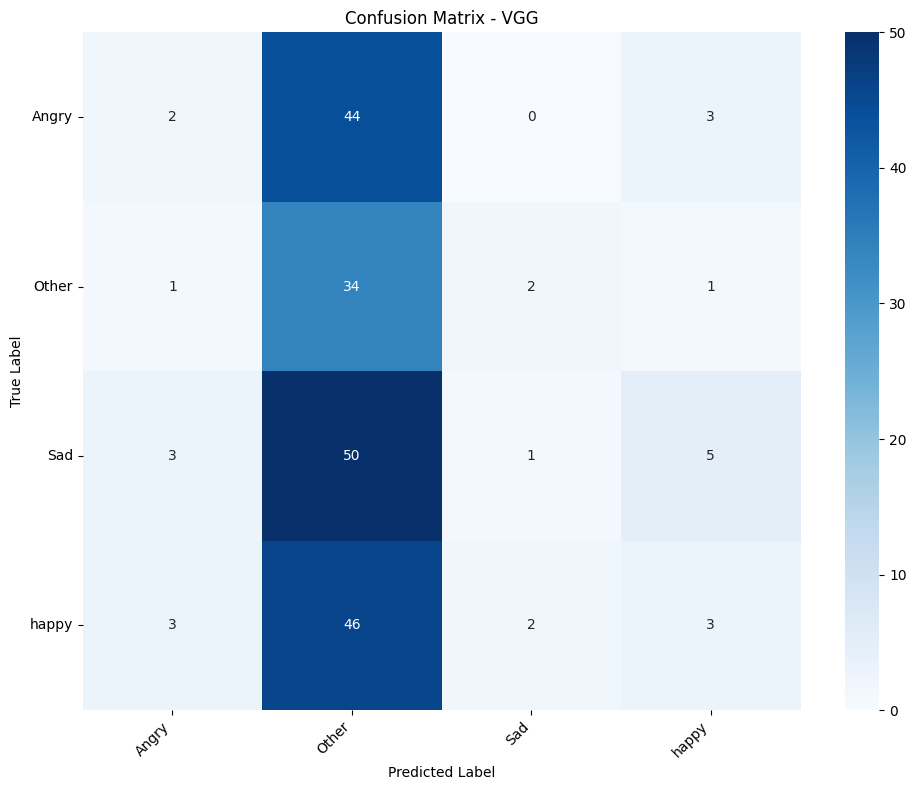

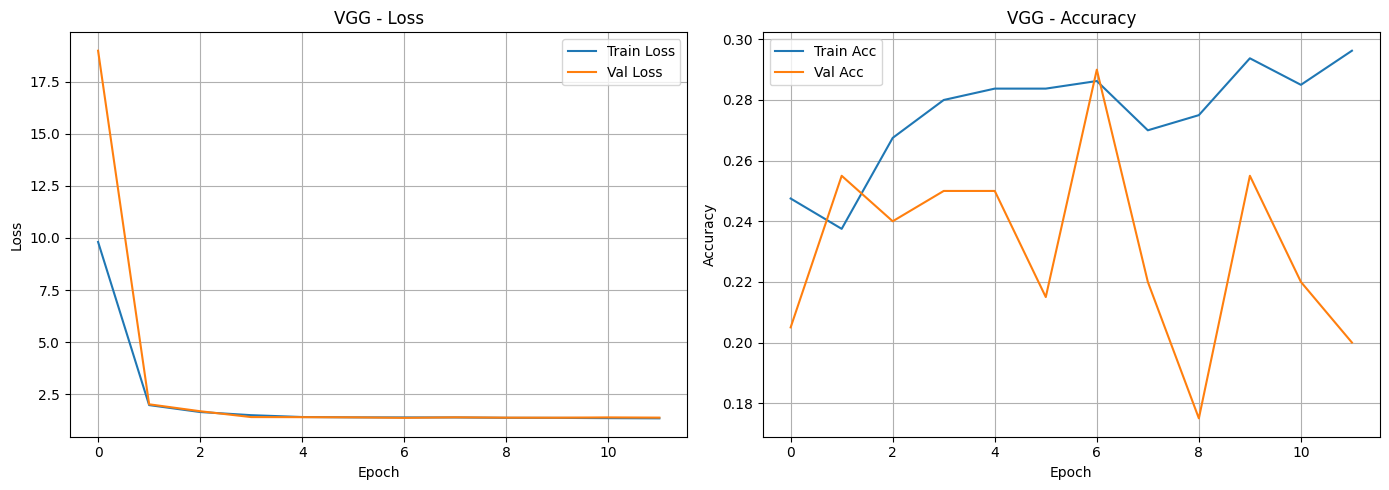


Classification Report - VGG:
              precision    recall  f1-score   support

       Angry     0.2222    0.0408    0.0690        49
       Other     0.1954    0.8947    0.3208        38
         Sad     0.2000    0.0169    0.0312        59
       happy     0.2500    0.0556    0.0909        54

    accuracy                         0.2000       200
   macro avg     0.2169    0.2520    0.1280       200
weighted avg     0.2181    0.2000    0.1116       200


ResNet: 11,178,564 trainable parameters
Training ResNet
____________________________________________________________
Epoch [01/25] | Train Loss: 1.5168, Acc: 0.2838 | Val Loss: 1.3889, Acc: 0.2800
Epoch [05/25] | Train Loss: 1.2910, Acc: 0.3650 | Val Loss: 1.3885, Acc: 0.3400
Epoch [10/25] | Train Loss: 1.1483, Acc: 0.4963 | Val Loss: 1.5461, Acc: 0.3350
Epoch [15/25] | Train Loss: 0.7002, Acc: 0.7300 | Val Loss: 1.6416, Acc: 0.4050

Early stopping triggered after 19 epochs (no validation loss improvement for 5 epochs).
Best Val

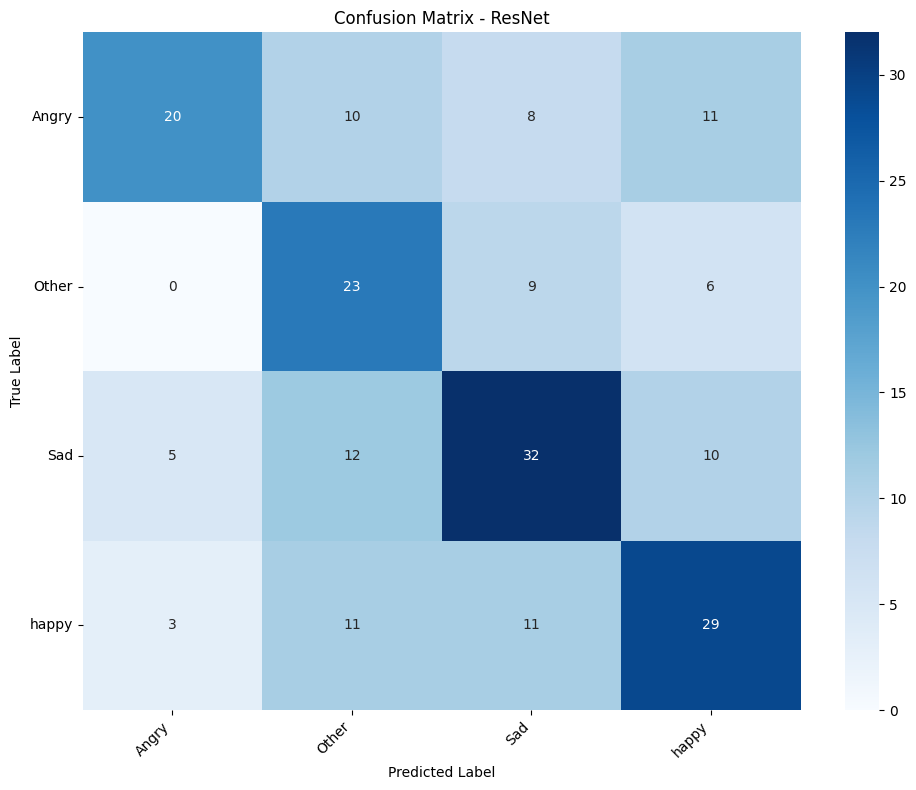

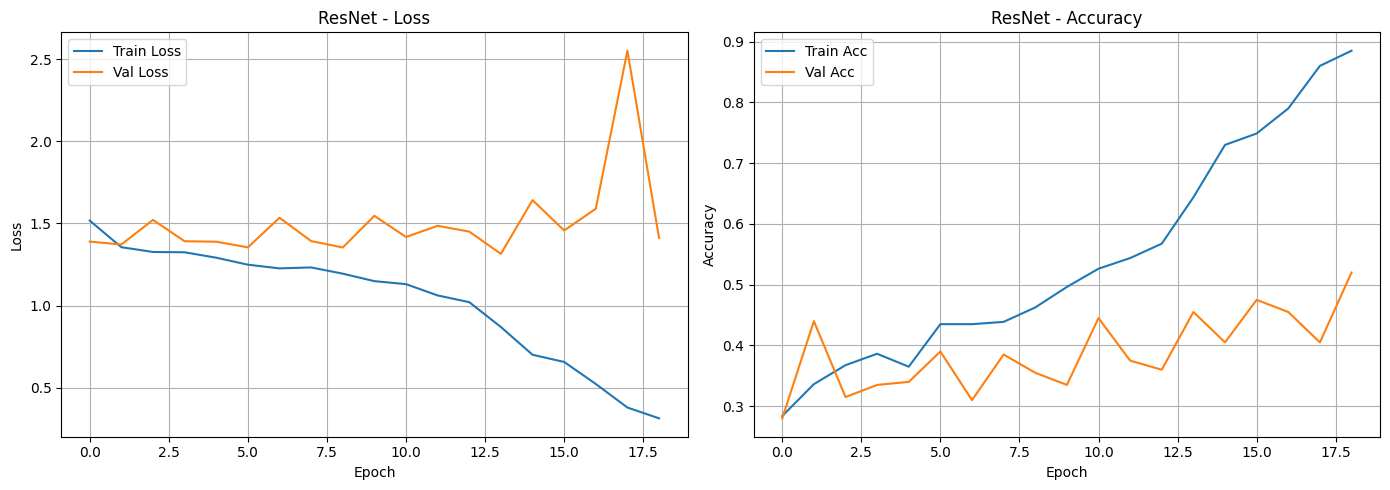


Classification Report - ResNet:
              precision    recall  f1-score   support

       Angry     0.7143    0.4082    0.5195        49
       Other     0.4107    0.6053    0.4894        38
         Sad     0.5333    0.5424    0.5378        59
       happy     0.5179    0.5370    0.5273        54

    accuracy                         0.5200       200
   macro avg     0.5440    0.5232    0.5185       200
weighted avg     0.5502    0.5200    0.5213       200


MobileNet: 3,211,076 trainable parameters
Training MobileNet
____________________________________________________________
Epoch [01/25] | Train Loss: 1.4556, Acc: 0.2875 | Val Loss: 1.6082, Acc: 0.2700
Epoch [05/25] | Train Loss: 1.1710, Acc: 0.4875 | Val Loss: 1.5434, Acc: 0.3350

Early stopping triggered after 8 epochs (no validation loss improvement for 5 epochs).
Best Validation Accuracy: 0.3250

MobileNet Final Metrics:
  Accuracy:  0.4300
  Precision: 0.4613
  Recall:    0.4373
  F1-Score:  0.4390


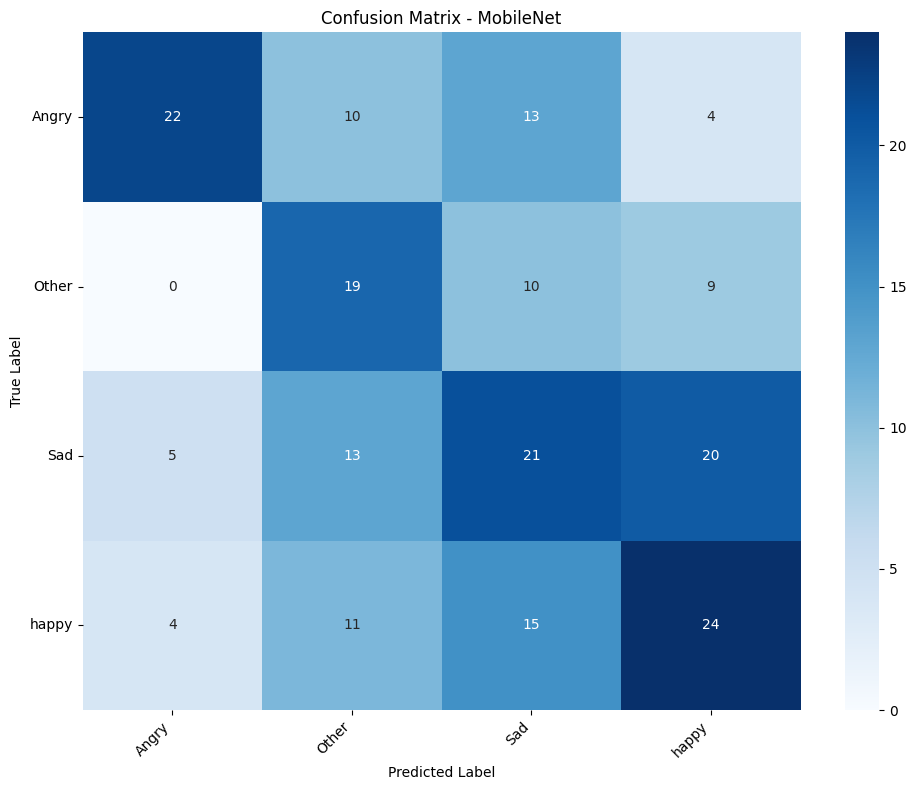

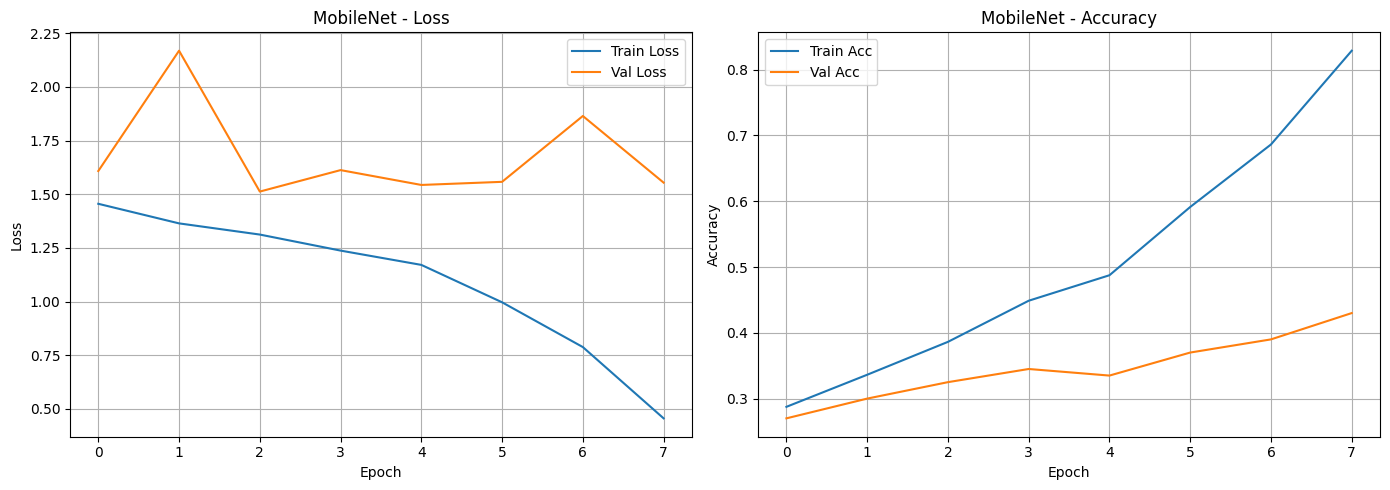


Classification Report - MobileNet:
              precision    recall  f1-score   support

       Angry     0.7097    0.4490    0.5500        49
       Other     0.3585    0.5000    0.4176        38
         Sad     0.3559    0.3559    0.3559        59
       happy     0.4211    0.4444    0.4324        54

    accuracy                         0.4300       200
   macro avg     0.4613    0.4373    0.4390       200
weighted avg     0.4607    0.4300    0.4358       200


InceptionNet: 4,531,236 trainable parameters
Training InceptionNet
____________________________________________________________
Epoch [01/25] | Train Loss: 1.4958, Acc: 0.3150 | Val Loss: 1.5542, Acc: 0.2650
Epoch [05/25] | Train Loss: 1.2805, Acc: 0.4288 | Val Loss: 1.4256, Acc: 0.3400
Epoch [10/25] | Train Loss: 1.0348, Acc: 0.5463 | Val Loss: 1.4809, Acc: 0.3700

Early stopping triggered after 12 epochs (no validation loss improvement for 5 epochs).
Best Validation Accuracy: 0.4100

InceptionNet Final Metrics:
  Accurac

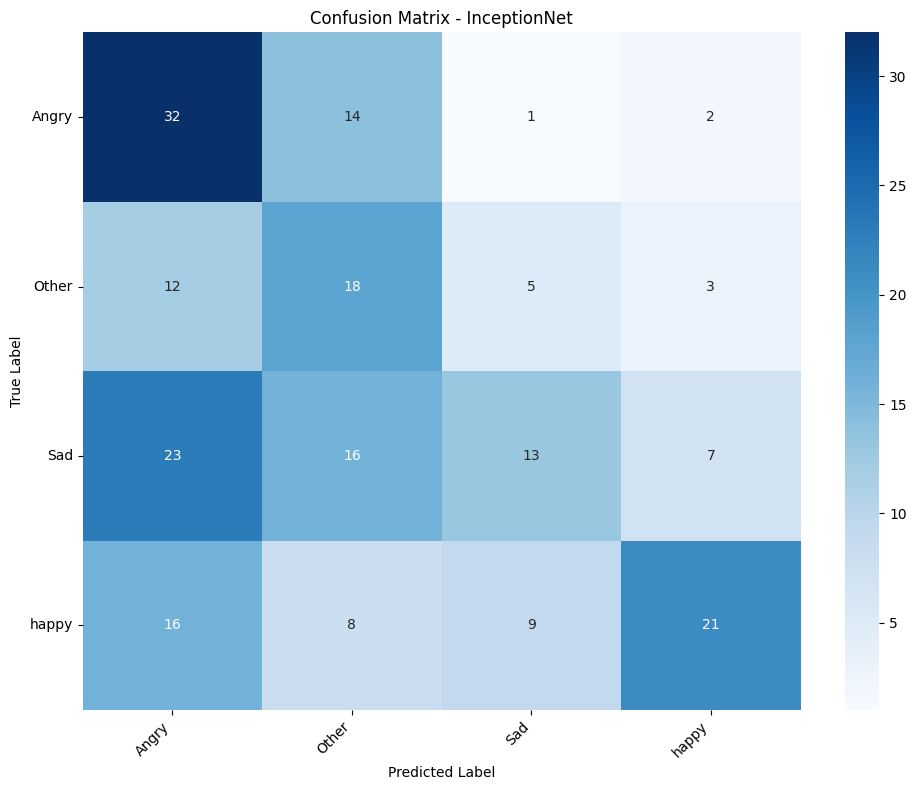

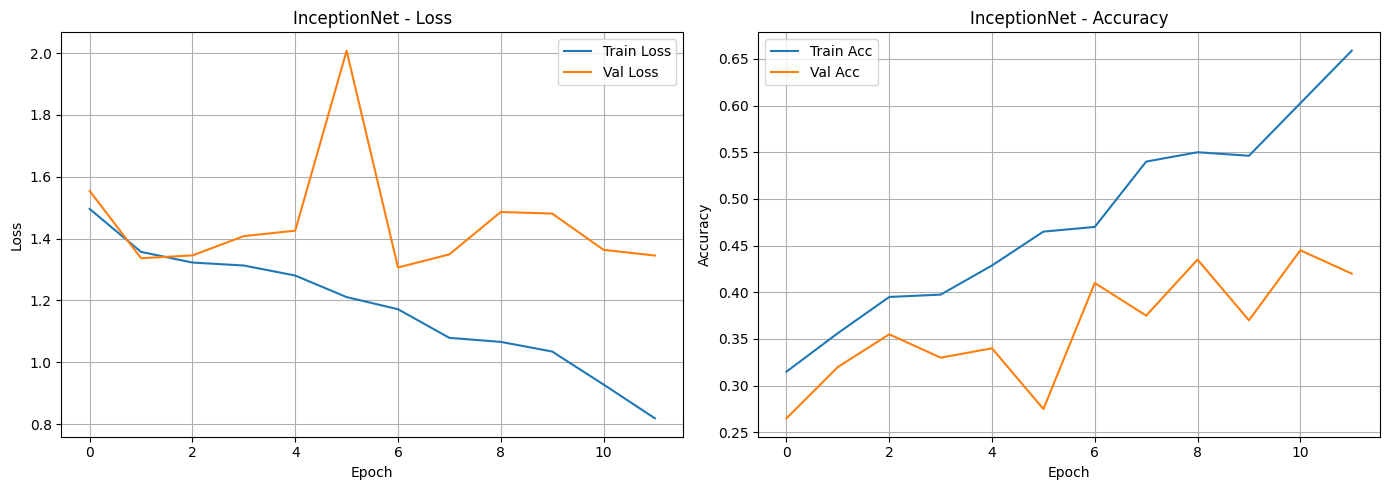


Classification Report - InceptionNet:
              precision    recall  f1-score   support

       Angry     0.3855    0.6531    0.4848        49
       Other     0.3214    0.4737    0.3830        38
         Sad     0.4643    0.2203    0.2989        59
       happy     0.6364    0.3889    0.4828        54

    accuracy                         0.4200       200
   macro avg     0.4519    0.4340    0.4124       200
weighted avg     0.4643    0.4200    0.4101       200


DenseNet: 1,823,884 trainable parameters
Training DenseNet
____________________________________________________________
Epoch [01/25] | Train Loss: 1.4255, Acc: 0.2913 | Val Loss: 1.4176, Acc: 0.2000
Epoch [05/25] | Train Loss: 1.3020, Acc: 0.3912 | Val Loss: 1.3378, Acc: 0.3100
Epoch [10/25] | Train Loss: 1.1990, Acc: 0.4387 | Val Loss: 1.2723, Acc: 0.3650
Epoch [15/25] | Train Loss: 1.0118, Acc: 0.5813 | Val Loss: 1.2269, Acc: 0.4400
Epoch [20/25] | Train Loss: 0.7484, Acc: 0.7150 | Val Loss: 1.3736, Acc: 0.4600
Epoch

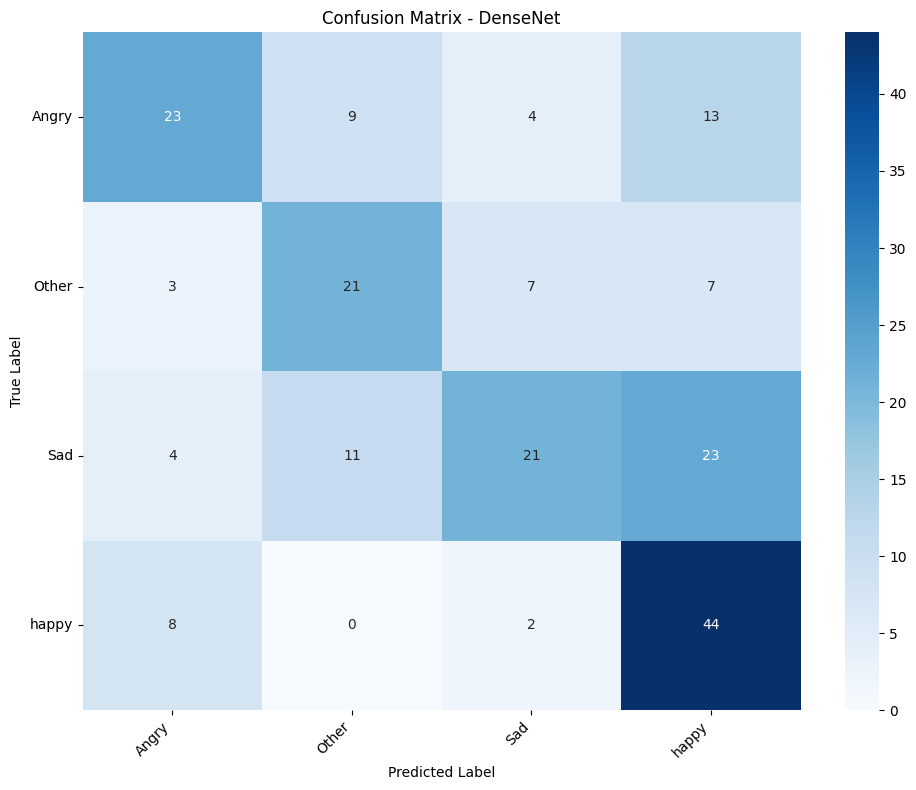

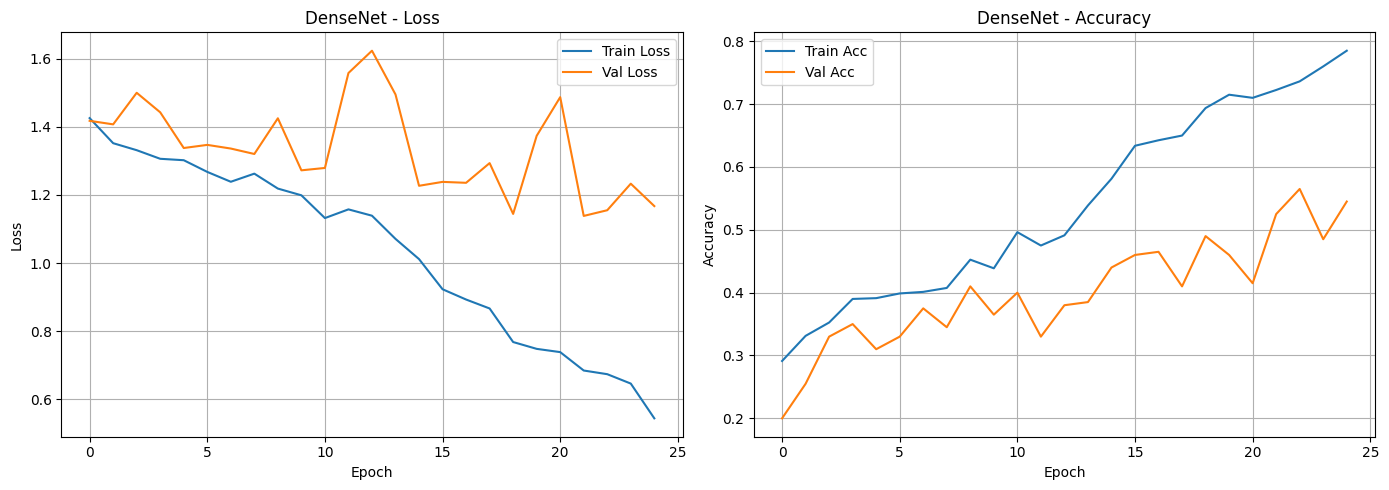


Classification Report - DenseNet:
              precision    recall  f1-score   support

       Angry     0.6053    0.4694    0.5287        49
       Other     0.5122    0.5526    0.5316        38
         Sad     0.6176    0.3559    0.4516        59
       happy     0.5057    0.8148    0.6241        54

    accuracy                         0.5450       200
   macro avg     0.5602    0.5482    0.5340       200
weighted avg     0.5644    0.5450    0.5323       200



In [27]:
# TRAIN ALL MODELS FROM SCRATCH

# Store results for all models
all_results = {}
all_histories = {}

# Define models
model_configs = {
    'VGG': VGG(num_classes),
    'ResNet': ResNet(num_classes),
    'MobileNet': MobileNet(num_classes),
    'InceptionNet': InceptionNet(num_classes),
    'DenseNet': DenseNet(num_classes, growth_rate=16, block_config=(6, 12, 24, 16))  # Smaller for speed
}

# Loss function
criterion = nn.CrossEntropyLoss()

# Train each model
for model_name, model in model_configs.items():
    model = model.to(device)
    
    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\n{model_name}: {trainable_params:,} trainable parameters")
    
    # Optimizer and scheduler
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=1e-4)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)
    
    # Train
    model, history, best_acc = train_model(
        model, train_loader, val_loader, criterion, optimizer, scheduler,
        NUM_EPOCHS, device, model_name
    )
    
    # Get full metrics
    metrics, y_true, y_pred = get_full_metrics(model, val_loader, class_names, device, model_name)
    
    # Store results
    all_results[model_name] = {
        'model': model,
        'metrics': metrics,
        'y_true': y_true,
        'y_pred': y_pred,
        'best_acc': best_acc
    }
    all_histories[model_name] = history
    
    # Print metrics
    print(f"\n{model_name} Final Metrics:")
    print(f"  Accuracy:  {metrics['accuracy']:.4f}")
    print(f"  Precision: {metrics['precision']:.4f}")
    print(f"  Recall:    {metrics['recall']:.4f}")
    print(f"  F1-Score:  {metrics['f1_score']:.4f}")
    
    # Plot confusion matrix
    plot_confusion_matrix(y_true, y_pred, class_names, model_name)
    
    # Plot training history
    plot_training_history(history, model_name)
    
    # Classification report
    print(f"\nClassification Report - {model_name}:")
    print(classification_report(y_true, y_pred, target_names=class_names, digits=4))


MODEL COMPARISON (Trained from Scratch)
       Model  Accuracy  Precision   Recall  F1-Score
    DenseNet     0.545   0.560213 0.548192  0.534027
      ResNet     0.520   0.544048 0.523209  0.518483
   MobileNet     0.430   0.461288 0.437339  0.438987
InceptionNet     0.420   0.451905 0.433993  0.412359
         VGG     0.200   0.216906 0.252014  0.127970


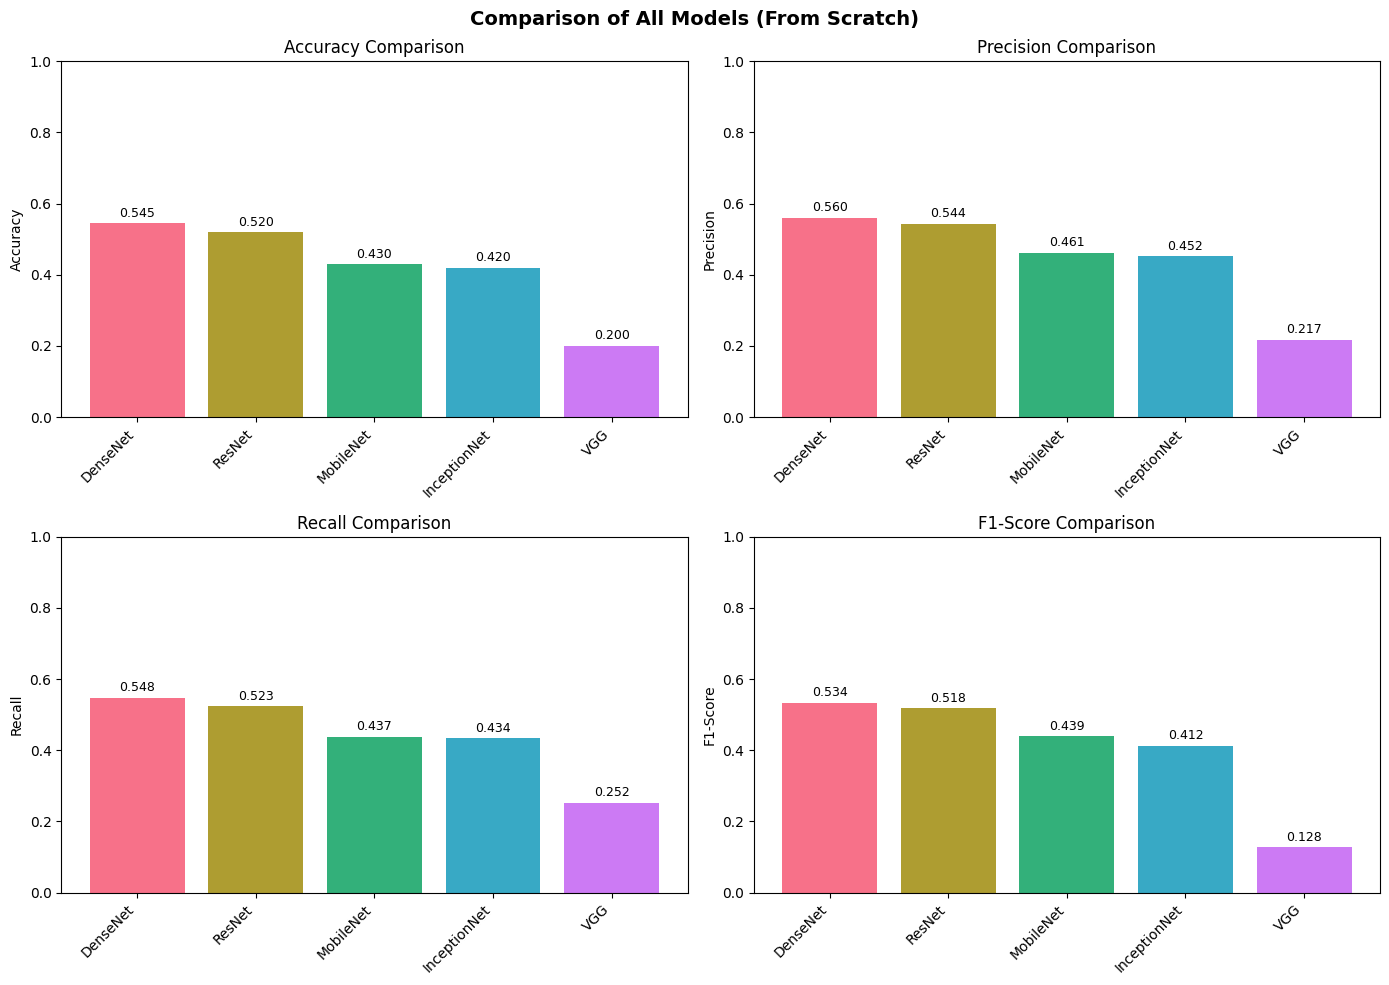


 Best Performing Model (From Scratch): DenseNet
   Accuracy: 0.5450


In [28]:
# COMPARE ALL MODELS

# Create comparison dataframe
comparison_data = []
for model_name, result in all_results.items():
    comparison_data.append({
        'Model': model_name,
        'Accuracy': result['metrics']['accuracy'],
        'Precision': result['metrics']['precision'],
        'Recall': result['metrics']['recall'],
        'F1-Score': result['metrics']['f1_score']
    })

comparison_df = pd.DataFrame(comparison_data)
comparison_df = comparison_df.sort_values('Accuracy', ascending=False)
print("\n" + "="*70)
print("MODEL COMPARISON (Trained from Scratch)")
print("="*70)
print(comparison_df.to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
colors = sns.color_palette("husl", len(comparison_df))

for ax, metric in zip(axes.flat, metrics_to_plot):
    bars = ax.bar(comparison_df['Model'], comparison_df[metric], color=colors)
    ax.set_title(f'{metric} Comparison')
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1)
    ax.set_xticklabels(comparison_df['Model'], rotation=45, ha='right')
    
    # Add value labels
    for bar, val in zip(bars, comparison_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                f'{val:.3f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comparison of All Models (From Scratch)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Find best model
best_model_name = comparison_df.iloc[0]['Model']
print(f"\n Best Performing Model (From Scratch): {best_model_name}")
print(f"   Accuracy: {comparison_df.iloc[0]['Accuracy']:.4f}")

# Part 3: Transfer Learning

Now we apply transfer learning using ImageNet pretrained weights to the best performing architecture from Part 2. We will use the built-in PyTorch models with pretrained weights.

In [29]:
# TRANSFER LEARNING SETUP

# Mapping from our scratch models to pretrained PyTorch models
pretrained_model_mapping = {
    'VGG': ('vgg16', models.vgg16, models.VGG16_Weights.IMAGENET1K_V1),
    'ResNet': ('resnet18', models.resnet18, models.ResNet18_Weights.IMAGENET1K_V1),
    'MobileNet': ('mobilenet_v2', models.mobilenet_v2, models.MobileNet_V2_Weights.IMAGENET1K_V1),
    'InceptionNet': ('inception_v3', models.inception_v3, models.Inception_V3_Weights.IMAGENET1K_V1),
    'DenseNet': ('densenet121', models.densenet121, models.DenseNet121_Weights.IMAGENET1K_V1)
}

def get_pretrained_model(model_name, num_classes):
    """Get pretrained model with modified classifier"""
    
    if model_name == 'VGG':
        model = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1)
        model.classifier[6] = nn.Linear(4096, num_classes)
        
    elif model_name == 'ResNet':
        model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'MobileNet':
        model = models.mobilenet_v2(weights=models.MobileNet_V2_Weights.IMAGENET1K_V1)
        model.classifier[1] = nn.Linear(model.classifier[1].in_features, num_classes)
        
    elif model_name == 'InceptionNet':
        model = models.inception_v3(weights=models.Inception_V3_Weights.IMAGENET1K_V1)
        model.aux_logits = False
        model.fc = nn.Linear(model.fc.in_features, num_classes)
        
    elif model_name == 'DenseNet':
        model = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
        model.classifier = nn.Linear(model.classifier.in_features, num_classes)
    
    return model

print("Transfer learning setup ready ✓")

Transfer learning setup ready ✓


In [30]:
# TRAIN BEST MODEL WITH TRANSFER LEARNING
print(f"\n{'='*70}")
print(f"TRANSFER LEARNING: Training {best_model_name} with ImageNet Weights")
print(f"{'='*70}")

# Get pretrained model
transfer_model = get_pretrained_model(best_model_name, num_classes).to(device)

# Count parameters
total_params = sum(p.numel() for p in transfer_model.parameters())
trainable_params = sum(p.numel() for p in transfer_model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")

# Stage 1: Freeze backbone, train only classifier
print("\n--- Stage 1: Training classifier head only ---")
for param in transfer_model.parameters():
    param.requires_grad = False

# Unfreeze classifier
if best_model_name == 'VGG':
    for param in transfer_model.classifier.parameters():
        param.requires_grad = True
elif best_model_name == 'ResNet':
    for param in transfer_model.fc.parameters():
        param.requires_grad = True
elif best_model_name == 'MobileNet':
    for param in transfer_model.classifier.parameters():
        param.requires_grad = True
elif best_model_name == 'InceptionNet':
    for param in transfer_model.fc.parameters():
        param.requires_grad = True
elif best_model_name == 'DenseNet':
    for param in transfer_model.classifier.parameters():
        param.requires_grad = True

# Optimizer for stage 1
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, transfer_model.parameters()), 
                             lr=1e-3, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

# Train stage 1
transfer_model, history_stage1, _ = train_model(
    transfer_model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=10, device=device, model_name=f"{best_model_name} (Stage 1 - Head)"
)


TRANSFER LEARNING: Training DenseNet with ImageNet Weights
Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 96.3MB/s]

Total parameters: 6,957,956
Trainable parameters: 6,957,956

--- Stage 1: Training classifier head only ---
Training DenseNet (Stage 1 - Head)
____________________________________________________________


Epoch [01/10] | Train Loss: 1.3081, Acc: 0.3688 | Val Loss: 1.2410, Acc: 0.4150
Epoch [05/10] | Train Loss: 0.8868, Acc: 0.6562 | Val Loss: 1.0090, Acc: 0.6000
Epoch [10/10] | Train Loss: 0.6931, Acc: 0.7700 | Val Loss: 0.9094, Acc: 0.6250
Best Validation Accuracy: 0.6250


In [31]:
# Stage 2: Fine-tune entire model with lower learning rate
print("\n--- Stage 2: Fine-tuning entire model ---")

# Unfreeze all parameters
for param in transfer_model.parameters():
    param.requires_grad = True

# Optimizer for stage 2 (lower lr for pretrained layers)
optimizer = torch.optim.Adam(transfer_model.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=3)

# Train stage 2
transfer_model, history_stage2, transfer_best_acc = train_model(
    transfer_model, train_loader, val_loader, criterion, optimizer, scheduler,
    num_epochs=15, device=device, model_name=f"{best_model_name} (Stage 2 - Full)"
)

# Combine histories
transfer_history = {
    'train_loss': history_stage1['train_loss'] + history_stage2['train_loss'],
    'train_acc': history_stage1['train_acc'] + history_stage2['train_acc'],
    'val_loss': history_stage1['val_loss'] + history_stage2['val_loss'],
    'val_acc': history_stage1['val_acc'] + history_stage2['val_acc']
}


--- Stage 2: Fine-tuning entire model ---
Training DenseNet (Stage 2 - Full)
____________________________________________________________
Epoch [01/15] | Train Loss: 0.5836, Acc: 0.8275 | Val Loss: 0.4449, Acc: 0.8750
Epoch [05/15] | Train Loss: 0.0128, Acc: 1.0000 | Val Loss: 0.2160, Acc: 0.9350
Epoch [10/15] | Train Loss: 0.0039, Acc: 1.0000 | Val Loss: 0.1862, Acc: 0.9450
Epoch [15/15] | Train Loss: 0.0013, Acc: 1.0000 | Val Loss: 0.1869, Acc: 0.9500
Best Validation Accuracy: 0.9500



TRANSFER LEARNING RESULTS: DenseNet
Accuracy:  0.9500
Precision: 0.9503
Recall:    0.9521
F1-Score:  0.9504


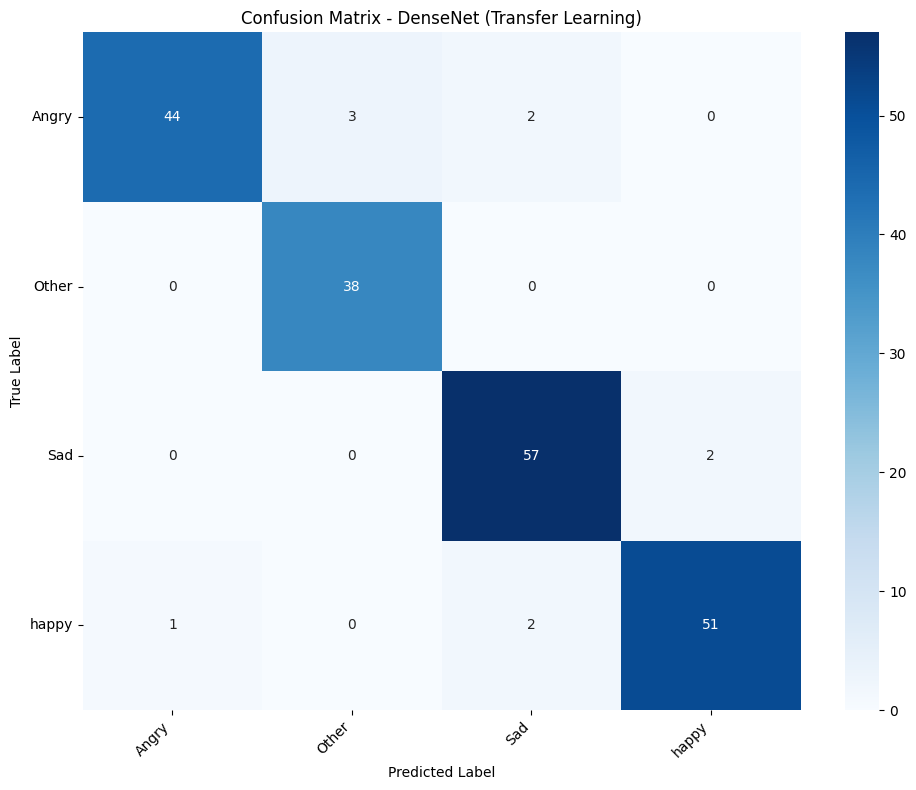

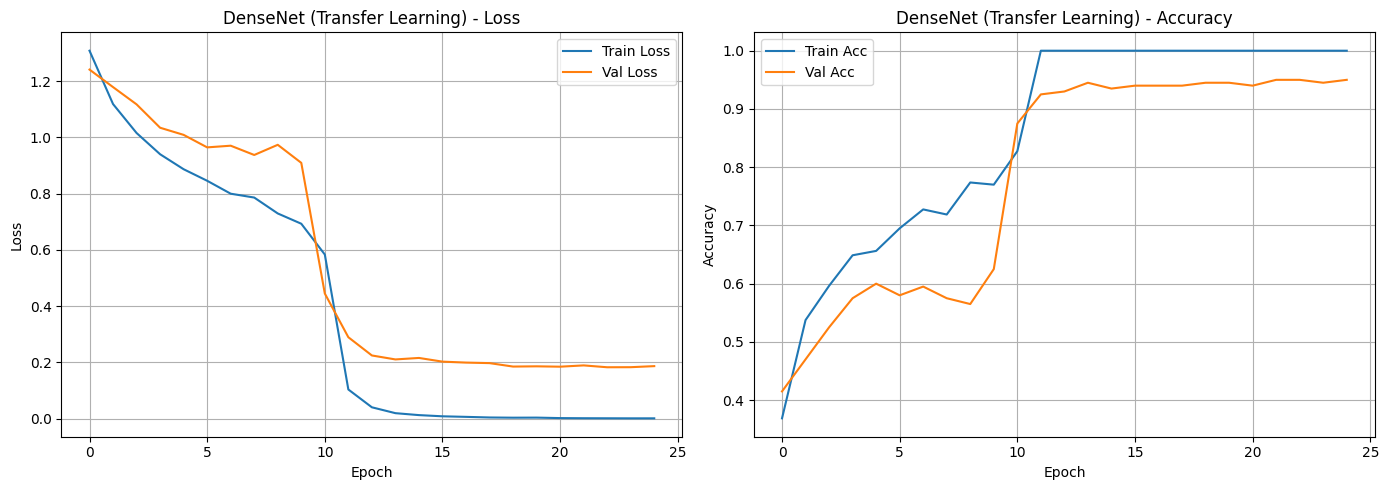


Classification Report - DenseNet (Transfer Learning):
              precision    recall  f1-score   support

       Angry     0.9778    0.8980    0.9362        49
       Other     0.9268    1.0000    0.9620        38
         Sad     0.9344    0.9661    0.9500        59
       happy     0.9623    0.9444    0.9533        54

    accuracy                         0.9500       200
   macro avg     0.9503    0.9521    0.9504       200
weighted avg     0.9511    0.9500    0.9498       200



In [32]:
# EVALUATE TRANSFER LEARNING MODEL

# Get metrics for transfer learning model
transfer_metrics, transfer_y_true, transfer_y_pred = get_full_metrics(
    transfer_model, val_loader, class_names, device, f"{best_model_name} (Transfer)"
)

print(f"\n{'='*70}")
print(f"TRANSFER LEARNING RESULTS: {best_model_name}")
print(f"{'='*70}")
print(f"Accuracy:  {transfer_metrics['accuracy']:.4f}")
print(f"Precision: {transfer_metrics['precision']:.4f}")
print(f"Recall:    {transfer_metrics['recall']:.4f}")
print(f"F1-Score:  {transfer_metrics['f1_score']:.4f}")

# Plot confusion matrix
plot_confusion_matrix(transfer_y_true, transfer_y_pred, class_names, 
                      f"{best_model_name} (Transfer Learning)")

# Plot training history
plot_training_history(transfer_history, f"{best_model_name} (Transfer Learning)")

# Classification report
print(f"\nClassification Report - {best_model_name} (Transfer Learning):")
print(classification_report(transfer_y_true, transfer_y_pred, target_names=class_names, digits=4))



FINAL COMPARISON: Scratch vs Transfer Learning
______________________________________________________________________

Model: DenseNet
  Training Method  Accuracy  Precision   Recall  F1-Score
     From Scratch     0.545   0.560213 0.548192  0.534027
Transfer Learning     0.950   0.950324 0.952126  0.950367


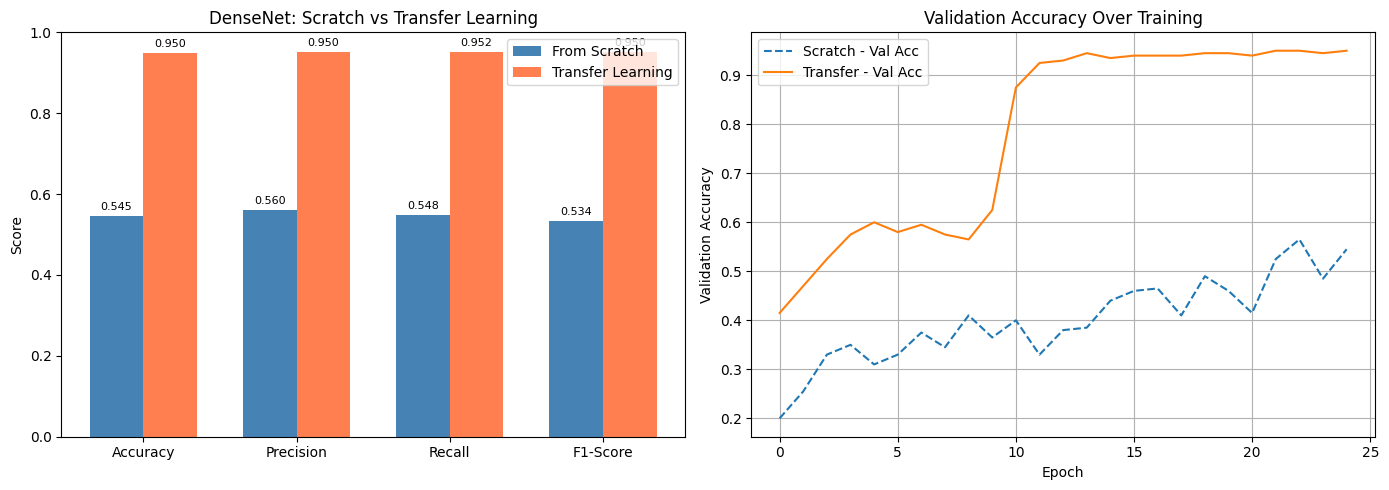


📊 IMPROVEMENT WITH TRANSFER LEARNING: +40.50%


In [37]:
# COMPARE: SCRATCH vs TRANSFER LEARNING

print("\n")
print("FINAL COMPARISON: Scratch vs Transfer Learning")
print("_"*70)

scratch_acc = all_results[best_model_name]['metrics']['accuracy']
transfer_acc = transfer_metrics['accuracy']
improvement = (transfer_acc - scratch_acc) * 100

comparison_final = pd.DataFrame({
    'Training Method': ['From Scratch', 'Transfer Learning'],
    'Accuracy': [all_results[best_model_name]['metrics']['accuracy'], transfer_metrics['accuracy']],
    'Precision': [all_results[best_model_name]['metrics']['precision'], transfer_metrics['precision']],
    'Recall': [all_results[best_model_name]['metrics']['recall'], transfer_metrics['recall']],
    'F1-Score': [all_results[best_model_name]['metrics']['f1_score'], transfer_metrics['f1_score']]
})

print(f"\nModel: {best_model_name}")
print(comparison_final.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar comparison
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(metrics_names))
width = 0.35

scratch_values = [all_results[best_model_name]['metrics']['accuracy'],
                  all_results[best_model_name]['metrics']['precision'],
                  all_results[best_model_name]['metrics']['recall'],
                  all_results[best_model_name]['metrics']['f1_score']]

transfer_values = [transfer_metrics['accuracy'],
                   transfer_metrics['precision'],
                   transfer_metrics['recall'],
                   transfer_metrics['f1_score']]

bars1 = axes[0].bar(x - width/2, scratch_values, width, label='From Scratch', color='steelblue')
bars2 = axes[0].bar(x + width/2, transfer_values, width, label='Transfer Learning', color='coral')

axes[0].set_ylabel('Score')
axes[0].set_title(f'{best_model_name}: Scratch vs Transfer Learning')
axes[0].set_xticks(x)
axes[0].set_xticklabels(metrics_names)
axes[0].legend()
axes[0].set_ylim(0, 1)

# Add value labels
for bar, val in zip(bars1, scratch_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)
for bar, val in zip(bars2, transfer_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f'{val:.3f}', ha='center', va='bottom', fontsize=8)

# Training curves comparison
axes[1].plot(all_histories[best_model_name]['val_acc'], label='Scratch - Val Acc', linestyle='--')
axes[1].plot(transfer_history['val_acc'], label='Transfer - Val Acc', linestyle='-')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Validation Accuracy')
axes[1].set_title('Validation Accuracy Over Training')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

print(f"\n📊 IMPROVEMENT WITH TRANSFER LEARNING: {improvement:+.2f}%")

In [39]:
# FINAL SUMMARY
print("\n")
print(" FINAL SUMMARY - PETS EXPRESSION CLASSIFICATION")
print("_"*70)

print("\n PART 1: Dataset")
print(f"   - Total Images: {len(full_dataset)}")
print(f"   - Number of Classes: {num_classes}")
print(f"   - Classes: {class_names}")
print(f"   - Train/Val Split: {1-VAL_SPLIT:.0%}/{VAL_SPLIT:.0%}")

print("\n PART 2: Models Built From Scratch")
print("-" * 50)
for model_name in ['VGG', 'ResNet', 'MobileNet', 'InceptionNet', 'DenseNet']:
    metrics = all_results[model_name]['metrics']
    print(f"   {model_name:15s} | Acc: {metrics['accuracy']:.4f} | "
          f"P: {metrics['precision']:.4f} | R: {metrics['recall']:.4f} | F1: {metrics['f1_score']:.4f}")

print(f"\n  Best Model (Scratch): {best_model_name}")

print("\n PART 3: Transfer Learning")
print("-" * 50)
print(f"   Model: {best_model_name} with ImageNet weights")
print(f"   Accuracy:  {transfer_metrics['accuracy']:.4f}")
print(f"   Precision: {transfer_metrics['precision']:.4f}")
print(f"   Recall:    {transfer_metrics['recall']:.4f}")
print(f"   F1-Score:  {transfer_metrics['f1_score']:.4f}")

print(f"\n IMPROVEMENT: {improvement:+.2f}% accuracy with Transfer Learning")



 FINAL SUMMARY - PETS EXPRESSION CLASSIFICATION
______________________________________________________________________

 PART 1: Dataset
   - Total Images: 1000
   - Number of Classes: 4
   - Classes: ['Angry', 'Other', 'Sad', 'happy']
   - Train/Val Split: 80%/20%

 PART 2: Models Built From Scratch
--------------------------------------------------
   VGG             | Acc: 0.2000 | P: 0.2169 | R: 0.2520 | F1: 0.1280
   ResNet          | Acc: 0.5200 | P: 0.5440 | R: 0.5232 | F1: 0.5185
   MobileNet       | Acc: 0.4300 | P: 0.4613 | R: 0.4373 | F1: 0.4390
   InceptionNet    | Acc: 0.4200 | P: 0.4519 | R: 0.4340 | F1: 0.4124
   DenseNet        | Acc: 0.5450 | P: 0.5602 | R: 0.5482 | F1: 0.5340

  Best Model (Scratch): DenseNet

 PART 3: Transfer Learning
--------------------------------------------------
   Model: DenseNet with ImageNet weights
   Accuracy:  0.9500
   Precision: 0.9503
   Recall:    0.9521
   F1-Score:  0.9504

 IMPROVEMENT: +40.50% accuracy with Transfer Learning
